# Task 3: Heart Disease Prediction

**DevelopersHub Corporation — AI/ML Engineering Internship**

## Objective
Predict heart disease risk from clinical attributes using binary classification.

## Dataset
UCI Heart Disease (Cleveland) — 303 patients, 14 attributes.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, RocCurveDisplay
)

sns.set_theme(style='whitegrid')
%matplotlib inline


## 1. Load & Clean Data


In [2]:
# UCI Cleveland heart disease dataset
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

raw = pd.read_csv(url, names=columns, na_values='?')
print('Shape before cleaning:', raw.shape)
print('Missing values:\n', raw.isnull().sum())

df = raw.dropna().copy()
# Binary target: 0 = no disease, 1+ = disease
df['target'] = (df['target'] > 0).astype(int)
print('\nShape after cleaning:', df.shape)
df.head()


Shape before cleaning: (303, 14)
Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Shape after cleaning: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Exploratory Data Analysis


In [3]:
print(df.describe())
print('\nTarget distribution:\n', df['target'].value_counts(normalize=True))


              age         sex          cp    trestbps        chol         fbs  \
count  297.000000  297.000000  297.000000  297.000000  297.000000  297.000000   
mean    54.542088    0.676768    3.158249  131.693603  247.350168    0.144781   
std      9.049736    0.468500    0.964859   17.762806   51.997583    0.352474   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  243.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  276.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  297.000000  297.000000  297.000000  297.000000  297.000000  297.000000   
mean     0.996633  149.599327    0.326599    1.055556    1.602694    0.676768   
std      0.994914   22.9415

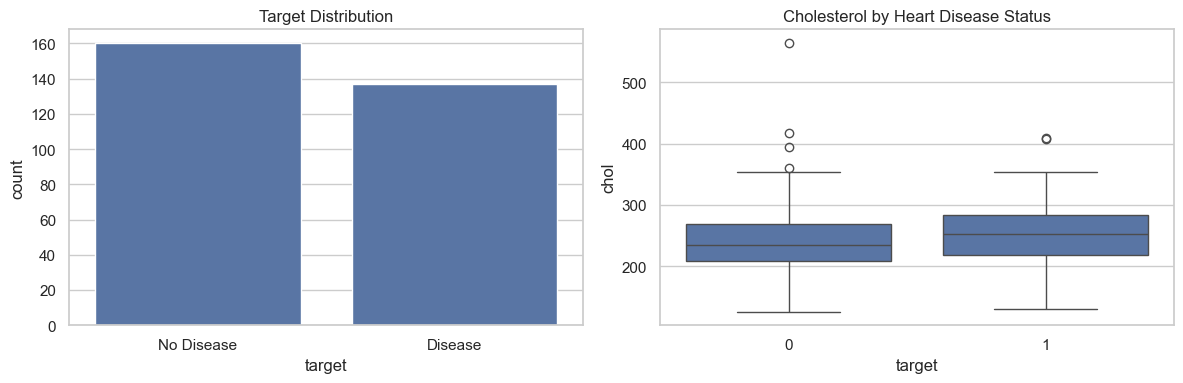

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='target', ax=axes[0])
axes[0].set_xticklabels(['No Disease', 'Disease'])
axes[0].set_title('Target Distribution')

sns.boxplot(data=df, x='target', y='chol', ax=axes[1])
axes[1].set_title('Cholesterol by Heart Disease Status')
plt.tight_layout()
plt.show()


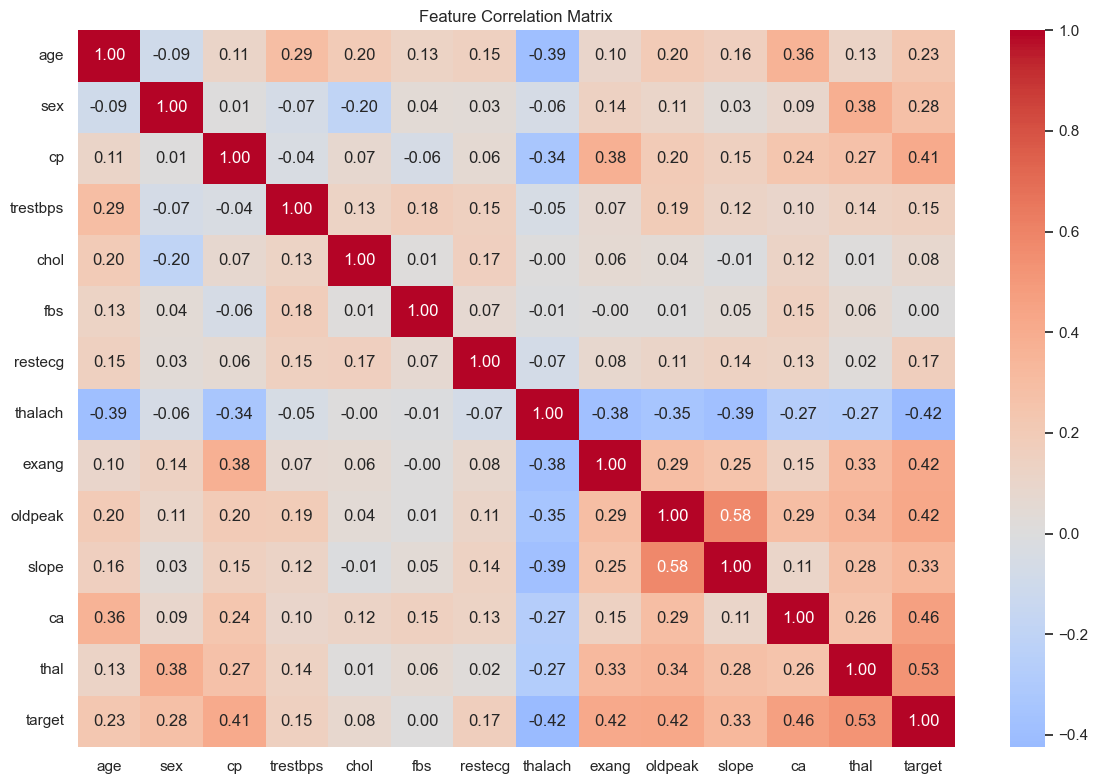

In [5]:
# Correlation heatmap (numeric columns)
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## 3. Train Classification Models


In [6]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_s, y_train)
y_pred_lr = log_reg.predict(X_test_s)
y_prob_lr = log_reg.predict_proba(X_test_s)[:, 1]

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

for name, yp, ypr in [('Logistic Regression', y_pred_lr, y_prob_lr),
                       ('Decision Tree', y_pred_dt, y_prob_dt)]:
    print(f'\n=== {name} ===')
    print('Accuracy:', round(accuracy_score(y_test, yp), 4))
    print(classification_report(y_test, yp, target_names=['No', 'Yes']))



=== Logistic Regression ===
Accuracy: 0.8333
              precision    recall  f1-score   support

          No       0.82      0.88      0.85        32
         Yes       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60


=== Decision Tree ===
Accuracy: 0.7
              precision    recall  f1-score   support

          No       0.68      0.84      0.75        32
         Yes       0.75      0.54      0.62        28

    accuracy                           0.70        60
   macro avg       0.71      0.69      0.69        60
weighted avg       0.71      0.70      0.69        60



## 4. Confusion Matrix & ROC Curve


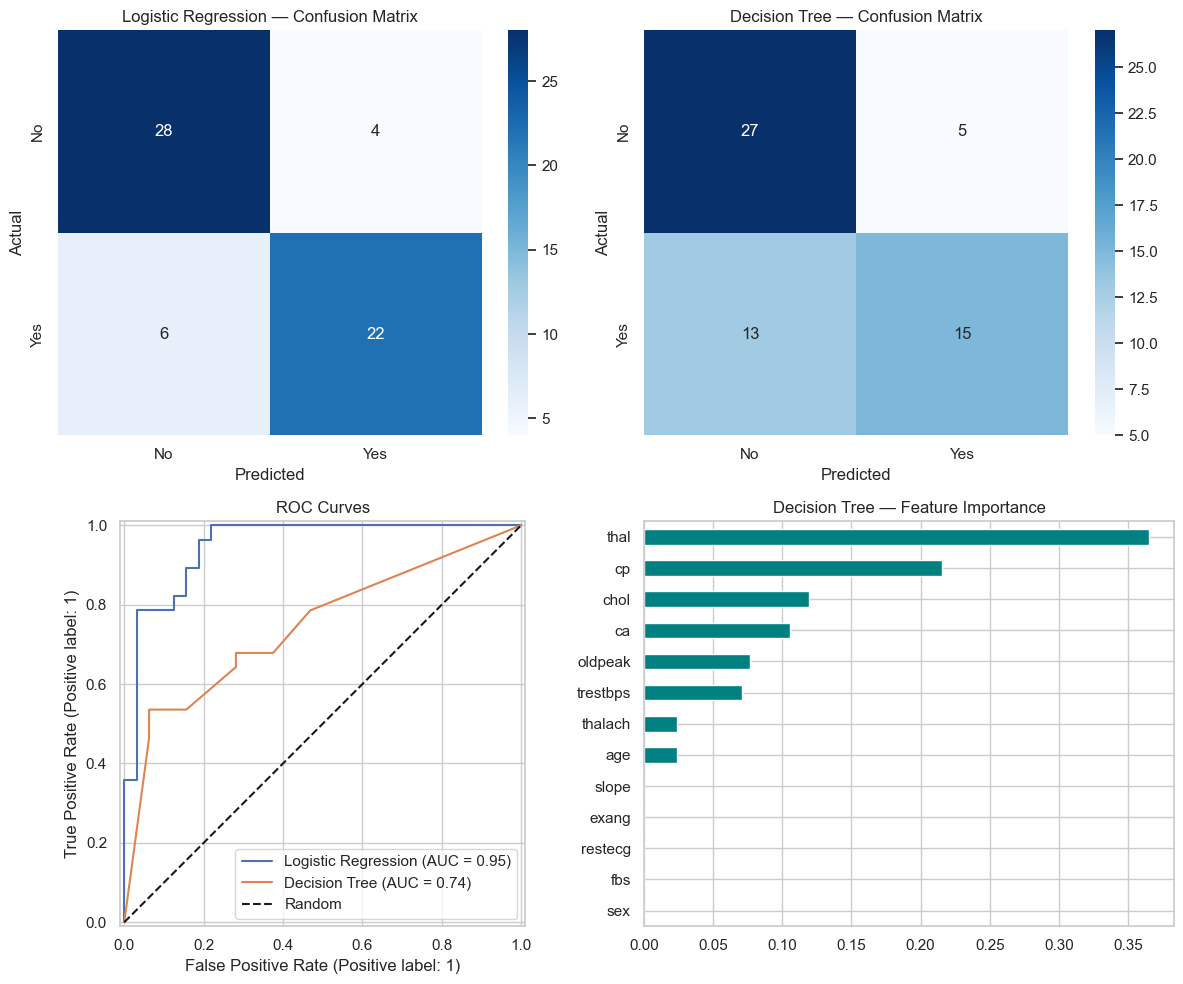

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, yp) in zip(axes[0], [('Logistic Regression', y_pred_lr), ('Decision Tree', y_pred_dt)]):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=axes[1, 0], name='Logistic Regression')
RocCurveDisplay.from_predictions(y_test, y_prob_dt, ax=axes[1, 0], name='Decision Tree')
axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1, 0].set_title('ROC Curves')
axes[1, 0].legend()

# Feature importance (Decision Tree)
imp = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=True)
imp.plot(kind='barh', ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Decision Tree — Feature Importance')

plt.tight_layout()
plt.show()


In [8]:
# Logistic regression coefficients (importance direction)
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print('Top features (Logistic Regression):')
print(coef_df.head(8).to_string(index=False))


Top features (Logistic Regression):
 feature  coefficient
      ca     0.958461
    thal     0.738613
      cp     0.507960
     sex     0.484582
 oldpeak     0.444296
trestbps     0.420218
   exang     0.372644
   slope     0.352973


## 5. Insights

- **cp** (chest pain type), **thalach** (max heart rate), and **oldpeak** (ST depression) are among the strongest predictors.
- Logistic Regression provides interpretable coefficients; Decision Tree gives non-linear splits.
- ROC-AUC above 0.85 indicates good discriminative ability on this hold-out set.
- **Disclaimer:** This model is for education only — not for clinical diagnosis.
